In [26]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random
import imageio
import os
from scipy.stats import mode
import skimage as ski
import time as tt
from mpl_toolkits.mplot3d import Axes3D
import csv
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import math
from scipy.optimize import curve_fit
import torch
from concurrent.futures import ProcessPoolExecutor

In [37]:

# =============================================================================
# Model Parameters
# =============================================================================
N = 100      # Number of agents
L = 10       # Number of different products
U = 11       # Number of product units each agent starts with
M = 20       # Memory length of each agent
t_max = 30000  # Total number of trade iterations
w = int(round(np.sqrt(N)))  # For 2D simulation, sqrt(N) should be an integer

# For the simulation, sigma is set to zero initially.
Default_cond = (t_max, N, L, U, M, 0, w)

# Define the device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
print(device)

cuda


In [35]:
# =============================================================================
# Functions for Agent Behavior
# =============================================================================

def AskN(i, I, T, c):
    """
    Ask function for NEED: Agent i chooses a product it needs if its inventory is <= 0.
    """
    # Use nonzero indices where condition holds
    need_i = (I[i, :] <= 0).nonzero(as_tuple=True)[0]
    if need_i.numel() > 0:
        # Randomly choose one index: generate a random index between 0 and numel-1
        rand_idx = torch.randint(0, need_i.numel(), (1,)).item()
        prod_i_want = need_i[rand_idx].item()
        c = "N"
    else:
        prod_i_want = -1
        c = "H"
    return prod_i_want, c


def AskG(i, I, T, c):
    """
    Ask function for GREED: Agent i chooses a product based on its memory or randomly.
    """
    # Get available memory entries (ignore -1)
    available = T[i][T[i] != -1]
    if available.numel() == 0:
        prod_i_want = torch.randint(0, L, (1,)).item()
    else:
        rand_idx = torch.randint(0, available.numel(), (1,)).item()
        prod_i_want = available[rand_idx].item()
    c = "G"
    return prod_i_want, c


def Ask(i, I, T, c):
    """
    Combined Ask function: Agent i prioritizes need (inventory zero) over greed.
    """
    need_i = (I[i, :] <= 0).nonzero(as_tuple=True)[0]
    available = T[i][T[i] != -1]
    if available.numel() == 0 and need_i.numel() == 0:
        prod_i_want = torch.randint(0, L, (1,)).item()
        c = "G"
    elif need_i.numel() > 0:
        rand_idx = torch.randint(0, need_i.numel(), (1,)).item()
        prod_i_want = need_i[rand_idx].item()
        c = "N"
    else:
        rand_idx = torch.randint(0, available.numel(), (1,)).item()
        prod_i_want = available[rand_idx].item()
        c = "G"
    return prod_i_want, c


# =============================================================================
# Functions for Trade and Memory Updates
# =============================================================================

def Trade(i, j, prod_i_want, prod_j_want, I, T):
    """
    Performs a trade between agents i and j exchanging products.
    """
    I[i, prod_j_want] -= 1
    I[j, prod_j_want] += 1
    I[j, prod_i_want] -= 1
    I[i, prod_i_want] += 1


def MemoryUpdate(i, j, prod_i_want, prod_j_want, I, T):
    """
    Updates the memory of agents i and j with the traded products.
    """
    memory_index = torch.randint(0, M, (2,))
    T[i, memory_index[0].item()] = prod_j_want
    T[j, memory_index[1].item()] = prod_i_want


def Pro_Consumption(i, sigma, I, T):
    """
    Handles production and consumption events for agent i based on a probability sigma.
    """
    # Use absolute value of a normal random sample
    if abs(torch.randn(1).item()) <= sigma and sigma != 0:
        available = T[i][T[i] != -1]
        if available.numel() == 0:
            prod_produce = torch.randint(0, L, (1,)).item()
        else:
            rand_idx = torch.randint(0, available.numel(), (1,)).item()
            prod_produce = available[rand_idx].item()
        I[i, prod_produce] += 1

        # Choose a product that agent i has
        has_i = (I[i, :] != 0).nonzero(as_tuple=True)[0]
        if has_i.numel() > 0:
            rand_idx = torch.randint(0, has_i.numel(), (1,)).item()
            prod_consume = has_i[rand_idx].item()
            I[i, prod_consume] -= 1


# =============================================================================
# Functions for Selecting Agents and News
# =============================================================================

def pick_agents1D(Amount, cons, Agent_grid):
    """
    Picks two distinct agents randomly (1D).
    """
    # Use a random permutation of agents and take first two
    indices = torch.randperm(N)[:2]
    return indices[0].item(), indices[1].item()


def pick_agents2D(Amount, cons, Agent_grid):
    """
    Picks two distinct agents from a 2D grid with periodic boundaries.
    """
    x = torch.randint(0, w, (1,)).item()
    y = torch.randint(0, w, (1,)).item()
    i = Agent_grid[x, y].item()

    while True:
        dx = torch.randint(-cons, cons + 1, (1,)).item()
        dy = torch.randint(-cons, cons + 1, (1,)).item()
        x2 = (x + dx) % w
        y2 = (y + dy) % w
        j = Agent_grid[x2, y2].item()
        if i != j:
            return i, j


def weighted_random(M_ignored):
    """
    Returns a weighted random integer based on an exponential decay.
    The decay parameter (L/9) is adjusted accordingly.
    """
    # Create weights for products 1 to L
    x = torch.arange(1, L + 1, dtype=torch.float)
    weights = torch.exp(-x / (L / 9))
    weights = weights / weights.sum()
    # torch.multinomial returns indices in the range [0, L-1]
    idx = torch.multinomial(weights, 1).item()
    # Return product number in 1...L instead of index
    return idx + 1


def news1D(Amount, sigma, L, Agent_grid, I, T):
    """
    Placeholder for news effect in 1D.
    """
    # Currently does nothing
    x = Amount


def news2D(Amount, sigma, L, Agent_grid, I, T):
    """
    Updates the memory of agents in a 2D grid based on weighted news.
    """
    if abs(torch.randn(1).item()) <= sigma:
        prod_news = torch.randint(0, L, (1,)).item()
        news_weight = weighted_random(M)
        # Select a random coordinate within the grid
        x1 = torch.randint(0, w, (1,)).item()
        y1 = torch.randint(0, w, (1,)).item()
        # Define neighbor coordinates with wrapping
        x0, y0 = (x1 - 1) % w, (y1 - 1) % w
        x2, y2 = (x1 + 1) % w, (y1 + 1) % w

        # Collect agents in a 3x3 neighborhood
        neighborhood = [
            Agent_grid[x0, y0].item(), Agent_grid[x0, y1].item(), Agent_grid[x0, y2].item(),
            Agent_grid[x1, y0].item(), Agent_grid[x1, y1].item(), Agent_grid[x1, y2].item(),
            Agent_grid[x2, y0].item(), Agent_grid[x2, y1].item(), Agent_grid[x2, y2].item()
        ]
        for ag in neighborhood:
            for _ in range(news_weight):
                memory_index = torch.randint(0, M, (1,)).item()
                T[ag, memory_index] = prod_news


# =============================================================================
# Utility Functions
# =============================================================================

def random_min_index(lst):
    """
    Chooses a random index among the indices corresponding to the minimum value in a list.
    """
    min_value = min(lst)
    min_indices = [i for i, val in enumerate(lst) if val == min_value]
    return random.choice(min_indices)


def most_prominent(arr):
    """
    Counts the most prominent (frequent) element in each row of arr, ignoring -1.
    Returns a tensor of the most frequent elements per row.
    """
    result = []
    for row in arr:
        filtered_row = [x for x in row if x != -1]
        if not filtered_row:
            result.append(0)
        else:
            counter = Counter(filtered_row)
            max_count = max(counter.values())
            # Get the first candidate with the maximum count
            candidates = [num for num in filtered_row if counter[num] == max_count]
            result.append(candidates[0])
    return torch.tensor(result)


def Hurst(L_list, T_window):
    """
    Computes an estimate for the Hurst exponent based on a given time window.
    """
    Temp = []
    # Assuming L_list is indexable and its elements are convertible to torch tensors/floats
    for i in range(len(L_list) - T_window):
        # use math.log or torch.log on float numbers
        c = (math.log(L_list[i + T_window]) - math.log(L_list[i])) ** 2
        Temp.append(c)
    return sum(Temp) / len(Temp) if Temp else 0


def count_elements_in_chunks(data, t_max, L):
    """
    Counts occurrences of each product in chunks of the timeline.
    """
    num_chunks = t_max // 50
    counts = torch.full((num_chunks, L + 1), float('nan'))
    
    for i in range(num_chunks):
        chunk = data[i * 100 : (i + 1) * 100]
        for p in range(L):
            # Count occurrences of product p in the chunk
            counts[i, p] = (chunk == p).sum().item()
        counts[i, p + 1] = i * 50
    return counts


def Talk(i, j, I, T):
    """
    Allows agents i and j to discuss a product.
    If both discuss the same product, update their memory.
    """
    available_i = T[i][T[i] != -1]
    if available_i.numel() == 0:
        prod_i_talk = torch.randint(0, L, (1,)).item()
    else:
        prod_i_talk = available_i[torch.randint(0, available_i.numel(), (1,)).item()].item()
    
    available_j = T[j][T[j] != -1]
    if available_j.numel() == 0:
        prod_j_talk = torch.randint(0, L, (1,)).item()
    else:
        prod_j_talk = available_j[torch.randint(0, available_j.numel(), (1,)).item()].item()
    
    if prod_i_talk == prod_j_talk:
        MemoryUpdate(i, j, prod_i_talk, prod_j_talk, I, T)


In [ ]:
import torch
import math
import random
from collections import Counter
import time as tt

# =============================================================================
# (Your original functions: AskN, AskG, Ask, Trade, MemoryUpdate, Pro_Consumption, 
#  weighted_random, news1D, news2D, Talk, etc.
#  These functions remain unchanged and are assumed to work on single‐simulation states
#  (i.e. I and T are 2D arrays with shape (N,L) or (N, M), and agent indices are scalars.)
# =============================================================================

# For example, your existing functions:
def AskN(i, I, T, c):
    need_i = (I[i, :] <= 0).nonzero(as_tuple=True)[0]
    if need_i.numel() > 0:
        rand_idx = torch.randint(0, need_i.numel(), (1,)).item()
        prod_i_want = need_i[rand_idx].item()
        c = "N"
    else:
        prod_i_want = -1
        c = "H"
    return prod_i_want, c

def AskG(i, I, T, c):
    available = T[i][T[i] != -1]
    if available.numel() == 0:
        prod_i_want = torch.randint(0, L, (1,)).item()
    else:
        rand_idx = torch.randint(0, available.numel(), (1,)).item()
        prod_i_want = available[rand_idx].item()
    c = "G"
    return prod_i_want, c

def Ask(i, I, T, c):
    need_i = (I[i, :] <= 0).nonzero(as_tuple=True)[0]
    available = T[i][T[i] != -1]
    if available.numel() == 0 and need_i.numel() == 0:
        prod_i_want = torch.randint(0, L, (1,)).item()
        c = "G"
    elif need_i.numel() > 0:
        rand_idx = torch.randint(0, need_i.numel(), (1,)).item()
        prod_i_want = need_i[rand_idx].item()
        c = "N"
    else:
        rand_idx = torch.randint(0, available.numel(), (1,)).item()
        prod_i_want = available[rand_idx].item()
        c = "G"
    return prod_i_want, c

def Trade(i, j, prod_i_want, prod_j_want, I, T):
    I[i, prod_j_want] -= 1
    I[j, prod_j_want] += 1
    I[j, prod_i_want] -= 1
    I[i, prod_i_want] += 1

def MemoryUpdate(i, j, prod_i_want, prod_j_want, I, T):
    memory_index = torch.randint(0, T.shape[1], (2,))
    T[i, memory_index[0].item()] = prod_j_want
    T[j, memory_index[1].item()] = prod_i_want

def Pro_Consumption(i, sigma, I, T):
    # Check using a random draw (note: using abs(torch.randn(1).item()) as in your code)
    if abs(torch.randn(1).item()) <= sigma and sigma != 0:
        available = T[i][T[i] != -1]
        if available.numel() == 0:
            prod_produce = torch.randint(0, L, (1,)).item()
        else:
            rand_idx = torch.randint(0, available.numel(), (1,)).item()
            prod_produce = available[rand_idx].item()
        I[i, prod_produce] += 1

        has_i = (I[i, :] != 0).nonzero(as_tuple=True)[0]
        if has_i.numel() > 0:
            rand_idx = torch.randint(0, has_i.numel(), (1,)).item()
            prod_consume = has_i[rand_idx].item()
            I[i, prod_consume] -= 1

# =============================================================================
# Batched helper: pick_agents1D_batch
# =============================================================================

def pick_agents1D_batch(B, N):
    """
    For each of the B simulations, pick two distinct random agents from 0 to N-1.
    Returns two tensors of shape (B,) containing the agent indices.
    """
    i_indices = torch.empty(B, dtype=torch.long)
    j_indices = torch.empty(B, dtype=torch.long)
    for b in range(B):
        idxs = torch.randperm(N)[:2]
        i_indices[b] = idxs[0]
        j_indices[b] = idxs[1]
    return i_indices, j_indices

# =============================================================================
# Main Batched Simulation Function
# =============================================================================

def Trade_Sim_Batch(Start_cond, D, Type, B):
    """
    Main simulation function that runs B independent simulation runs in parallel
    (vectorized over a batch dimension).
    
    Parameters:
      Start_cond: tuple containing (t_max, N, L, U, M, sigma, w)
      D: Dimension flag (we assume D==1 in this batched version)
      Type: Trade type indicator (2 for only greed, 3 for only need, other for combined)
      B: Batch size (number of parallel simulation runs)
    
    Returns:
      I_history: Tensor of shape (t_max, B, N, L)
      T_history: Tensor of shape (t_max, B, N, M)
      Frac: Tensor of shape (round(t_max/100)+1, B, 3)
      Trade_history: Tensor of shape (t_max*2, B)
      Demand_list: Tensor of shape (t_max, B, L)
      Agents_score: Tensor of shape (t_max, B, N)
    """
    t_max, N, L, U, M, sigma, w = Start_cond

    # Initialize inventory I and memory T with an extra batch dimension.
    I = torch.zeros((B, N, L), dtype=torch.int64)
    T = -torch.ones((B, N, M), dtype=torch.int64)

    # For each simulation in the batch, create a shuffled distribution of products.
    base_products = torch.arange(L)
    products = base_products.repeat(N // L).repeat(U)  # shape: (N*U,)
    for b in range(B):
        perm = torch.randperm(products.numel())
        prod_shuffled = products[perm]
        for idx, prod in enumerate(prod_shuffled):
            agent = idx % N
            I[b, agent, prod.item()] += 1

    # Prepare histories and tracking arrays with batch dimension.
    I_history    = torch.empty((t_max, B, N, L), dtype=torch.int64)
    T_history    = torch.empty((t_max, B, N, M), dtype=torch.int64)
    Demand_list  = torch.empty((t_max, B, L))
    Trade_history = -torch.ones((t_max * 2, B), dtype=torch.int64)
    Agents_score = torch.zeros((t_max, B, N))
    Frac         = torch.empty((round(t_max / 100) + 1, B, 3))

    # Counters for need vs. greed per simulation in the batch.
    cG = torch.zeros(B, dtype=torch.int64)
    cN = torch.zeros(B, dtype=torch.int64)
    # (c is an unused indicator variable in your asking functions)
    c = 0

    # Determine asking function based on trade type.
    if Type == 2:
        Asking = AskG
    elif Type == 3:
        Asking = AskN
    else:
        Asking = Ask

    # For 1D simulation we use our batched agent picker.
    pick_agents = pick_agents1D_batch

    # Main simulation loop (over t_max trade iterations).
    for trade in range(t_max):
        # Pick two distinct agents for each simulation in the batch.
        i_indices, j_indices = pick_agents(B, N)  # shape (B,) each

        # ----------------------------
        # Production/Consumption step:
        # ----------------------------
        for b in range(B):
            Pro_Consumption(i_indices[b].item(), sigma, I[b], T[b])
            Pro_Consumption(j_indices[b].item(), sigma, I[b], T[b])

        # ----------------------------
        # Agents decide what product they want (Ask step)
        # ----------------------------
        i_wants = []  # will hold chosen product for each batch run from the i-agent.
        j_wants = []  # similarly for the j-agent.
        cs1 = []      # indicator ("N" or "G") for i-agent.
        cs2 = []      # for j-agent.
        for b in range(B):
            prod_i, ci = Asking(i_indices[b].item(), I[b], T[b], c)
            prod_j, cj = Asking(j_indices[b].item(), I[b], T[b], c)
            i_wants.append(prod_i)
            cs1.append(ci)
            j_wants.append(prod_j)
            cs2.append(cj)
        # Convert lists to tensors.
        i_wants = torch.tensor(i_wants)
        j_wants = torch.tensor(j_wants)

        # ----------------------------
        # Update counters for need vs. greed per batch simulation.
        # ----------------------------
        for b in range(B):
            cN[b] += (1 if cs1[b] == "N" else 0) + (1 if cs2[b] == "N" else 0)
            cG[b] += (1 if cs1[b] == "G" else 0) + (1 if cs2[b] == "G" else 0)
        if (trade + 1) % 100 == 0:
            for b in range(B):
                Frac[(trade + 1) // 100, b] = torch.tensor(
                    [(trade + 1) // 100, cG[b].item() / 200, cN[b].item() / 200], dtype=torch.float
                )
                cG[b] = 0
                cN[b] = 0

        # ----------------------------
        # Process trades.
        # ----------------------------
        for b in range(B):
            # Check that both chosen products are valid and agents have available inventory.
            if (i_wants[b] != -1 and j_wants[b] != -1 and 
                I[b, i_indices[b], j_wants[b]] > 0 and 
                I[b, j_indices[b], i_wants[b]] > 0):
                # Process trade
                Trade(
                    i_indices[b].item(),
                    j_indices[b].item(),
                    int(i_wants[b]),
                    int(j_wants[b]),
                    I[b],
                    T[b]
                )
                if trade > 0:
                    Agents_score[trade, b, i_indices[b]] = (
                        Demand_list[trade - 1, b, int(i_wants[b])] - 
                        Demand_list[trade - 1, b, int(j_wants[b])]
                    )
                    Agents_score[trade, b, j_indices[b]] = (
                        Demand_list[trade - 1, b, int(j_wants[b])] - 
                        Demand_list[trade - 1, b, int(i_wants[b])]
                    )
                Trade_history[trade * 2:trade * 2 + 2, b] = torch.tensor([int(i_wants[b]), int(j_wants[b])])
            else:
                Trade_history[trade * 2:trade * 2 + 2, b] = torch.tensor([-1, -1])

        # ----------------------------
        # Update Demand list.
        # ----------------------------
        for b in range(B):
            for p in range(L):
                Demand_list[trade, b, p] = (T[b] == p).sum().item() / (N * M)

        # ----------------------------
        # Cumulative agent score update.
        # ----------------------------
        if trade > 0:
            Agents_score[trade, :, :] += Agents_score[trade - 1, :, :]

        # ----------------------------
        # Memory update.
        # ----------------------------
        for b in range(B):
            MemoryUpdate(
                i_indices[b].item(),
                j_indices[b].item(),
                int(i_wants[b]),
                int(j_wants[b]),
                I[b],
                T[b]
            )

        # ----------------------------
        # Save current state in histories.
        # ----------------------------
        for b in range(B):
            I_history[trade, b] = I[b].clone()
            T_history[trade, b] = T[b].clone()

    return I_history, T_history, Frac, Trade_history, Demand_list, Agents_score

# =============================================================================
# Example of running the batched simulation.
# =============================================================================

if __name__ == "__main__":
    # Define your parameters (example values)
    N = 100       # Number of agents
    L = 10        # Number of products
    U = 11        # Units per agent initially
    M = 20        # Memory length
    t_max = 30000 # Total iterations
    w = round(math.sqrt(N))
    sigma = 0.1   # or any sigma value (this example uses a single sigma for all runs)
    Start_cond = (t_max, N, L, U, M, sigma, w)
    
    B = 4  # Batch size = 4 parallel simulation runs
    start = tt.perf_counter()
    I_hist, T_hist, Frac, Trade_hist, Demand_list, Agents_score = Trade_Sim_Batch(Start_cond, D=1, Type=1, B=B)
    end = tt.perf_counter()
    print("Time taken:", end - start)


In [ ]:
# =============================================================================
# Example of running the batched simulation.
# =============================================================================

if __name__ == "__main__":
    # Define your parameters (example values)
    N = 100       # Number of agents
    L = 10        # Number of products
    U = 11        # Units per agent initially
    M = 20        # Memory length
    t_max = 30000 # Total iterations
    w = round(math.sqrt(N))
    sigma = 0.1   # or any sigma value (this example uses a single sigma for all runs)
    Start_cond = (t_max, N, L, U, M, sigma, w)
    
    B = 5 # Batch size = 4 parallel simulation runs
    start = tt.perf_counter()
    I_hist, T_hist, Frac, Trade_hist, Demand_list, Agents_score = Trade_Sim_Batch(Start_cond, D=1, Type=1, B=B)
    end = tt.perf_counter()
    print("Time taken:", end - start)

In [28]:

# List of sigma values you want to run
sigma_values = [i * 0.1 for i in range(4)]

start = tt.perf_counter()

# Run simulations in parallel
with ProcessPoolExecutor(max_workers=4) as executor:
    results = list(executor.map(run_simulation, sigma_values))

# Stack the results into a single tensor
RUN_LIST_demand = torch.stack(results)

print(tt.perf_counter() - start)

BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.

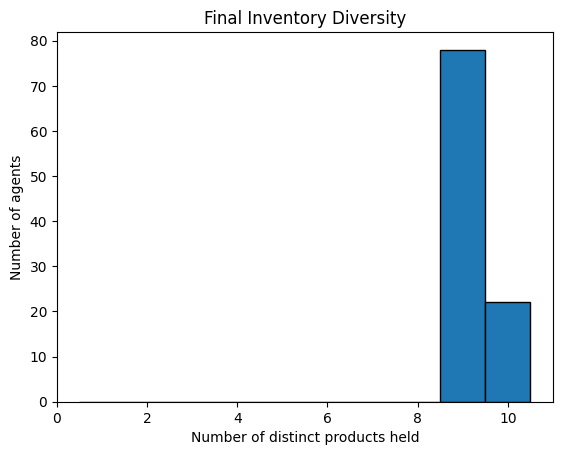

In [23]:
distinct_products = torch.sum(I_history[t_max-1] > 0, axis=1)
distinct_products = distinct_products.clone().detach().cpu().numpy()
plt.hist(distinct_products, bins=range(1, L+2), align='left', edgecolor='black')
plt.xlabel("Number of distinct products held")
plt.ylabel("Number of agents")
plt.title("Final Inventory Diversity")
plt.show()


In [ ]:
for i in range(10):
    

In [ ]:
if __name__ == '__main__':
    # For example, run with 2D simulation and normal trade (Type other than 2 or 3)
    I_history, T_history, Frac, Trade_history, Demand_list, Agents_score = Trade_Sim(Default_cond, D=1, Type=1)
    # Optionally, bring results back to CPU for further processing:
    I_history_cpu = I_history.cpu().numpy()
    print("Simulation complete. Final inventory snapshot:")
    print(I_history_cpu[-1])